Created by Lucía León Prieto

March, 2026

go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms
Proteínas totales: 129
Columnas: ['id_uniprot', 'gene_name', 'label', 'description', 'go_terms', 'PIL_Degree', 'PIL_Strength', 'PIL_Betweenness_Weighted', 'PIL_MCC', 'Global_Strength', 'Global_Betweenness_Weighted', 'Pleiotropy', 'Pathway_Size', 'Delta_Funcional']

Ejemplo GO terms (primera fila): ['activation of innate immune response', 'immune system process', 'DNA binding', 'left-handed Z-DNA binding', 'RNA binding', 'double-stranded RNA binding', 'double-stranded RNA adenosine deaminase activity', 'protein binding', 'nucleus', 'cytoplasm', 'cytosol', 'apoptotic process', 'programmed cell death', 'identical protein binding', 'positive regulation of apoptotic process', 'innate immune response', 'regulation of inflammatory response', 'positive regulation of inflammatory response', 'defense response to fungus', 'defense response to virus', 'positive regulation of type I interferon-mediated signaling pathway', 'positive regulation of n

/tmp/ipykernel_2364/1668159171.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_proteins = df_proteins[df["label"] == "protein"].copy().reset_index(drop=True)


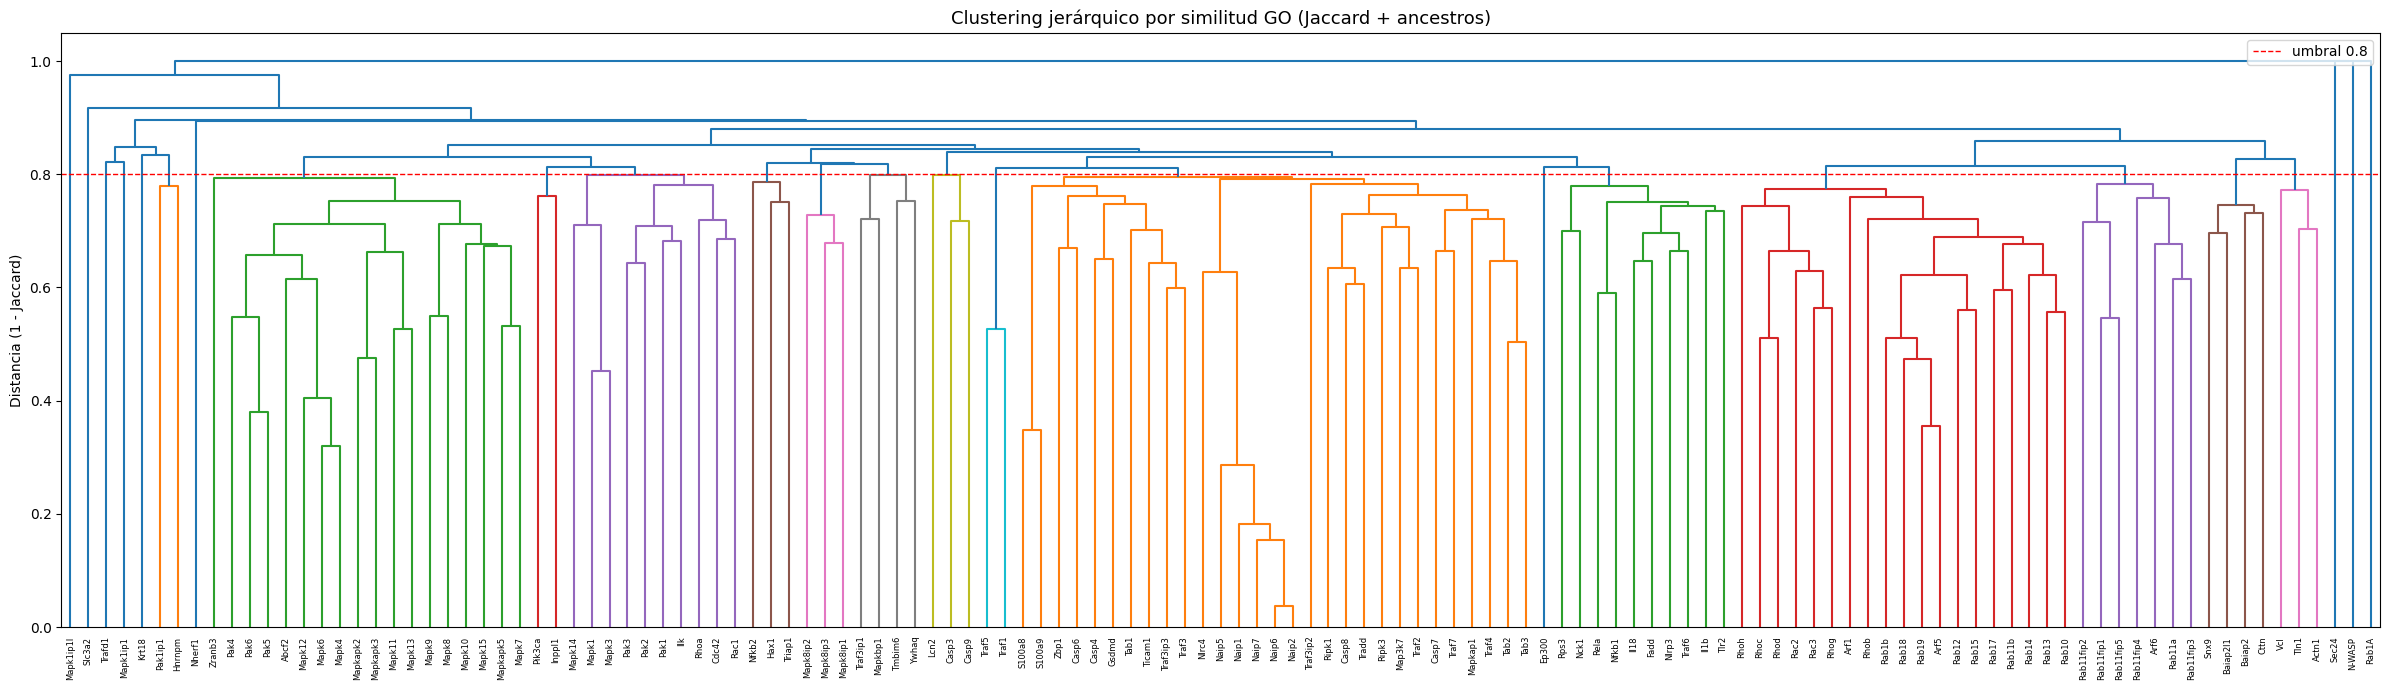

Dendrograma guardado en dendrograma_go_80.png

--- Número de clusters según umbral de corte ---
  Umbral 0.5: 117 clusters | max=  5, min= 1, media=1.1
  Umbral 0.6: 102 clusters | max=  5, min= 1, media=1.3
  Umbral 0.7:  71 clusters | max= 11, min= 1, media=1.8
  Umbral 0.79:  31 clusters | max= 19, min= 1, media=4.2
  Umbral 0.8:  25 clusters | max= 29, min= 1, media=5.2
  Umbral 0.9:   6 clusters | max=124, min= 1, media=21.5

Clusters con umbral 0.8:
protein_group
GO_cluster_01                                               [Trafd1]
GO_cluster_02                                             [Mapk1ip1]
GO_cluster_03                                      [Pak1ip1, Hnrnpm]
GO_cluster_04                                                [Krt18]
GO_cluster_05      [Mapk12, Mapkapk5, Mapkapk2, Mapkapk3, Mapk6, ...
GO_cluster_06                                       [Pik3ca, Inppl1]
GO_cluster_07      [Mapk14, Mapk1, Mapk3, Pak3, Pak2, Rhoa, Cdc42...
GO_cluster_08                              

In [27]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from goatools.obo_parser import GODag

# ── 1. Cargar ontología ───────────────────────────────────────────────────────
# Descarga previa desde terminal:
# wget http://purl.obolibrary.org/obo/go/go-basic.obo
godag = GODag("go-basic.obo")

# ── 2. Cargar y filtrar proteínas del huésped ─────────────────────────────────
df = pd.read_csv("Master_Node_Table_Only.csv")
interacciones = pd.read_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas.csv", sep=";")
all_proteins = np.unique(interacciones["Protein"])
pos_lines = interacciones[interacciones["Is_Connected"] == True]
pos_proteins = np.unique(pos_lines["Protein"])

df_proteins = df[df["gene_name"].isin(pos_proteins)]
df_proteins = df_proteins[df["label"] == "protein"].copy().reset_index(drop=True)

print(f"Proteínas totales: {len(df_proteins)}")
print(f"Columnas: {df_proteins.columns.tolist()}")
print(f"\nEjemplo GO terms (primera fila): {df_proteins['go_terms'].iloc[0]}")

# ── 3. Parsear GO terms ───────────────────────────────────────────────────────
# Detecta el separador automáticamente
separador = ";" if ";" in str(df_proteins["go_terms"].iloc[0]) else ","

# Transformamos los go terms de texto a identificadores numéricos
# Diccionario con equivalencias nombre:GO_id
name_to_id = {obj.name.lower(): obj.id for obj in godag.values()}
print(f"Diccionario de mapeo creado. Total términos: {len(name_to_id)}")

# Añadimos a nuestro data frame la columna con los identificadores
def get_go_ids(text):
    if pd.isna(text) or text == "":
        return []
    
    # Limpiar y separar los términos (maneja listas o strings con separadores)
    # Si el CSV ya viene formateado como lista de Python en el string:
    import ast
    try:
        terms = ast.literal_eval(text) if "[" in str(text) else text.split(separador)
    except:
        terms = str(text).split(separador)
    
    # Traducir nombres a IDs usando el diccionario name_to_id
    ids_encontrados = []
    for t in terms:
        clean_name = str(t).strip().lower()
        if clean_name in name_to_id:
            ids_encontrados.append(name_to_id[clean_name])
            
    return ids_encontrados

# Aplicar la función
df_proteins["go_terms_raw"] = df_proteins["go_terms"].apply(get_go_ids)

# Verificar resultados
con_go = (df_proteins["go_terms_raw"].apply(len) > 0).sum()
print(f"✅ Proteínas con IDs de GO encontrados: {con_go}/{len(df_proteins)}")

# df_proteins["go_terms_raw"] = df_proteins["go_terms"].fillna("").apply(
#     lambda x: [t.strip() for t in str(x).split(separador) if t.strip().startswith("GO:")]
# )

sin_go = (df_proteins["go_terms_raw"].apply(len) == 0).sum()
print(f"\n⚠️  Proteínas sin GO terms válidos: {sin_go}/{len(df_proteins)}")
print(f"   Proteínas con GO terms: {len(df_proteins) - sin_go}/{len(df_proteins)}")

# ── 4. Expandir con ancestros en la ontología ─────────────────────────────────
def expand_with_ancestors(go_terms, godag):
    """
    Expande una lista de GO terms con todos sus términos ancestrales.
    Sin expansión, dos proteínas con términos relacionados pero no idénticos
    tienen similitud Jaccard = 0, produciendo dendrograma plano.
    """
    expanded = set()
    n_not_found = 0
    for term in go_terms:
        if term in godag:
            expanded.add(term)
            expanded.update(godag[term].get_all_parents())
        else:
            n_not_found += 1
    return expanded

go_sets_raw      = df_proteins["go_terms_raw"].tolist()
go_sets_expanded = [expand_with_ancestors(terms, godag) for terms in go_sets_raw]

# Diagnóstico de expansión
n_terms_before = np.mean([len(s) for s in go_sets_raw])
n_terms_after  = np.mean([len(s) for s in go_sets_expanded])
print(f"\nTérminos por proteína antes de expandir: {n_terms_before:.1f}")
print(f"Términos por proteína después de expandir: {n_terms_after:.1f}")

# Proteínas que siguen sin términos tras expansión
no_terms_mask = [len(s) == 0 for s in go_sets_expanded]
if any(no_terms_mask):
    print(f"\n⚠️  {sum(no_terms_mask)} proteínas sin términos válidos en la ontología:")
    print(df_proteins[no_terms_mask]["gene_name"].tolist())

# ── 5. Matriz de similitud Jaccard sobre términos expandidos ──────────────────
proteins = df_proteins["id_uniprot"].tolist()
genes    = df_proteins["gene_name"].tolist()
n        = len(proteins)

sim_matrix = np.eye(n)
total_pairs = n * (n - 1) // 2
done = 0

for i in range(n):
    for j in range(i + 1, n):
        set_i = go_sets_expanded[i]
        set_j = go_sets_expanded[j]
        if set_i and set_j:
            intersection = len(set_i & set_j)
            union        = len(set_i | set_j)
            sim          = intersection / union if union > 0 else 0.0
        else:
            sim = 0.0
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim
        done += 1
        if done % 1000 == 0:
            print(f"  {done}/{total_pairs} pares calculados...")

# Diagnóstico de similitudes
sim_vals = sim_matrix[np.triu_indices(n, k=1)]
print(f"\nRango de similitudes: {sim_vals.min():.4f} - {sim_vals.max():.4f}")
print(f"Media de similitudes: {sim_vals.mean():.4f}")
print(f"% pares con sim=0:    {(sim_vals == 0).sum() / len(sim_vals) * 100:.1f}%")
print(f"% pares con sim>0.1:  {(sim_vals > 0.1).sum() / len(sim_vals) * 100:.1f}%")

# ── 6. Clustering jerárquico ──────────────────────────────────────────────────
dist_matrix    = 1 - sim_matrix
np.fill_diagonal(dist_matrix, 0)
dist_condensed = squareform(dist_matrix, checks=False)
Z = linkage(dist_condensed, method="average")

# ── 7. Dendrograma ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 7))
dendrogram(
    Z,
    labels       = genes,
    leaf_rotation= 90,
    leaf_font_size= 6,
    ax           = ax,
    color_threshold= 0.8,  # línea de corte visual
)
ax.axhline(y=0.8, color="red", linestyle="--", linewidth=1, label="umbral 0.8")
ax.set_title("Clustering jerárquico por similitud GO (Jaccard + ancestros)", fontsize=13)
ax.set_ylabel("Distancia (1 - Jaccard)")
ax.legend()
plt.tight_layout()
plt.savefig("dendrograma_go_80.png", dpi=150)
plt.show()
print("Dendrograma guardado en dendrograma_go_80.png")

# ── 8. Distribución de clusters según umbral de distancia ────────────────────
print("\n--- Número de clusters según umbral de corte ---")
for umbral in [0.5, 0.6, 0.7, 0.79, 0.8, 0.9]:
    labels_tmp = fcluster(Z, t=umbral, criterion="distance")
    n_clusters = len(np.unique(labels_tmp))
    sizes      = pd.Series(labels_tmp).value_counts()
    print(f"  Umbral {umbral}: {n_clusters:>3} clusters | "
          f"max={sizes.max():>3}, min={sizes.min():>2}, "
          f"media={sizes.mean():.1f}")

# ── 9. Elegir umbral y guardar ────────────────────────────────────────────────
# Ajusta UMBRAL_CORTE tras ver la tabla y el dendrograma
UMBRAL_CORTE = 0.8

labels_final = fcluster(Z, t=UMBRAL_CORTE, criterion="distance")
df_proteins["protein_group"] = [f"GO_cluster_{c:02d}" for c in labels_final]

# Subdividimos el grupo 13 en tres subgrupos
g13 = "GO_cluster_13" 

# Extraer los miembros del grupo 13
mask_g13 = df_proteins["protein_group"] == g13
indices_g13 = df_proteins.index[mask_g13].tolist()
genes_g13 = [genes[i] for i in indices_g13]

if len(indices_g13) > 1:
    
    # Obtenemos las distancias originales de esos miembros
    sub_dist_matrix = dist_matrix[np.ix_(indices_g13, indices_g13)]
    sub_dist_condensed = squareform(sub_dist_matrix, checks=False)
    Z_sub = linkage(sub_dist_condensed, method="average")
    
    # Forzamos la división en 3 subgrupos usando el criterio 'maxclust'
    sub_labels = fcluster(Z_sub, t=3, criterion="maxclust")
    
    # Asignamos los nuevos nombres: "GO_cluster_13.1", "13.2", etc.
    df_proteins.loc[mask_g13, "protein_group"] = [f"GO_cluster_13.{l}" for l in sub_labels]
else:
    df_proteins.loc[mask_g13, "protein_group"] = "GO_cluster_13"

print(f"\nClusters con umbral {UMBRAL_CORTE}:")
print(df_proteins.groupby("protein_group")["gene_name"].apply(list).to_string())


df_proteins[["id_uniprot", "gene_name", "protein_group"]].to_csv(
    "protein_go_80_clusters_grupo13sep.csv", index=False
)
print("\nGuardado en protein_go_80_clusters_grupo13sep.csv")


In [13]:
df_proteins

,id_uniprot,gene_name,label,description,go_terms,PIL_Degree,PIL_Strength,PIL_Betweenness_Weighted,PIL_MCC,Global_Strength,Global_Betweenness_Weighted,Pleiotropy,Pathway_Size,Delta_Funcional,go_terms_raw,protein_group
0,Q9QY24,Zbp1,protein,Z-DNA-binding protein 1 (DNA-dependent activat...,"['activation of innate immune response', 'immu...",1.0,0.7,0.000000,1.0,0.7,0.000000,0.0,0.0,0.000000,"[GO:0002218, GO:0002376, GO:0003677, GO:000369...",GO_cluster_13.1
1,Q9QZL0,Ripk3,protein,Receptor-interacting serine/threonine-protein ...,"['nucleotide binding', 'regulation of T cell m...",4.0,3.1,0.042324,4.0,3.1,0.026084,0.0,0.0,-0.016240,"[GO:0000166, GO:0001914, GO:0002819, GO:000467...",GO_cluster_13.3
2,P10749,Il1b,protein,Interleukin-1 beta (IL-1 beta),['negative regulation of transcription by RNA ...,6.0,4.2,0.124843,6.0,5.6,0.132680,2.0,0.0,0.007837,"[GO:0000122, GO:0001660, GO:0005125, GO:000514...",GO_cluster_14
3,P70380,Il18,protein,Interleukin-18 (IL-18) (Interferon gamma-induc...,"['angiogenesis', 'response to hypoxia', 'posit...",2.0,1.4,0.021277,2.0,2.1,0.081756,1.0,0.0,0.060479,"[GO:0001525, GO:0001666, GO:0001819, GO:000512...",GO_cluster_14
4,O89110,Casp8,protein,Caspase-8 (CASP-8) (EC 3.4.22.61) [Cleaved int...,"['angiogenesis', 'regulation of cytokine produ...",9.0,6.8,0.193074,9.0,8.2,0.152474,2.0,0.0,-0.040600,"[GO:0001525, GO:0001817, GO:0001841, GO:000268...",GO_cluster_13.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,P68254,Ywhaq,protein,14-3-3 protein theta (14-3-3 protein tau),"['protein binding', 'nucleus', 'cytoplasm', 'c...",0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,"[GO:0005515, GO:0005634, GO:0005737, GO:000582...",GO_cluster_10
125,Q9DBJ3,Baiap2l1,protein,BAR/IMD domain-containing adapter protein 2-li...,"['actin binding', 'nucleoplasm', 'cytoplasm', ...",0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,"[GO:0003779, GO:0005654, GO:0005737, GO:000582...",GO_cluster_18
126,O08611,Inppl1,protein,"Phosphatidylinositol 3,4,5-trisphosphate 5-pho...",['establishment of mitotic spindle orientation...,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,"[GO:0000132, GO:0000922, GO:0001958, GO:000237...",GO_cluster_06
127,Q3UGC2,Cttn,protein,Src substrate cortactin,"['ruffle', 'podosome', 'protein binding', 'pro...",0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,"[GO:0001726, GO:0002102, GO:0005515, GO:000552...",GO_cluster_18


In [14]:
# We make sure group 13 is correctly divided
df_proteins["gene_name"][df_proteins["protein_group"] == "GO_cluster_13.1"]

0          Zbp1
7         Casp6
15        Casp4
19         Tab1
21       Ticam1
24     Traf3ip3
30        Traf3
32        Gsdmd
105      S100a8
107      S100a9
Name: gene_name, dtype: str

In [15]:
df_proteins["gene_name"][df_proteins["protein_group"] == "GO_cluster_13.2"]

9     Naip7
10    Nlrc4
11    Naip6
12    Naip2
13    Naip1
14    Naip5
Name: gene_name, dtype: str

In [16]:
df_proteins["gene_name"][df_proteins["protein_group"] == "GO_cluster_13.3"]

1        Ripk3
4        Casp8
6        Casp7
8        Ripk1
18      Map3k7
20        Tab2
23       Traf2
25       Traf4
27       Traf7
29    Traf3ip2
39       Tradd
47     Mapkap1
51        Tab3
Name: gene_name, dtype: str

#### Representación gráfica

Ahora hacemos un dendrograma exclusivo del grupo 13 subdividido.

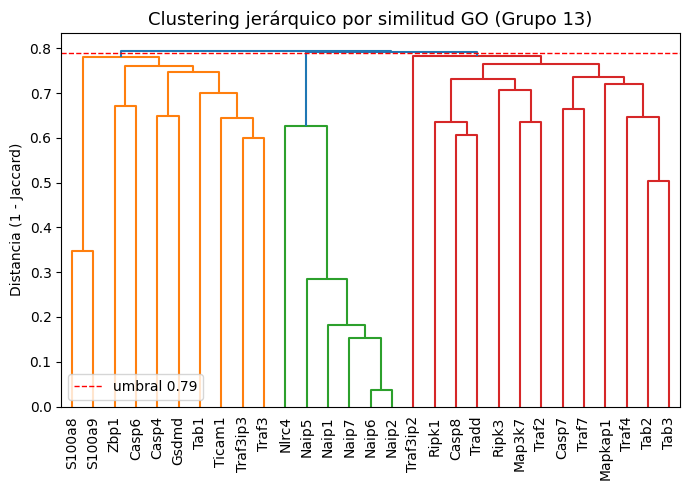

Dendrograma guardado en dendrograma_go_80_grupo13.png


In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
dendrogram(
    Z_sub,
    labels       = genes_g13,
    leaf_rotation= 90,
    leaf_font_size= 10,
    ax           = ax,
    color_threshold= 0.79,  # línea de corte visual
)
ax.axhline(y=0.79, color="red", linestyle="--", linewidth=1, label="umbral 0.79")
ax.set_title("Clustering jerárquico por similitud GO (Grupo 13)", fontsize=13)
ax.set_ylabel("Distancia (1 - Jaccard)")
ax.legend()
plt.tight_layout()
plt.savefig("dendrograma_go_80_grupo13.png", dpi=150)
plt.show()
print("Dendrograma guardado en dendrograma_go_80_grupo13.png")
